# B18 · Context-window failure and sufficient evidence

<p class="subtitle">Research bridge · preserve the evidence before choosing the predictor.</p>

[B17](https://avistian.github.io/relational/lessons/b17-reusable-representations.html) asked whether an encoder can reuse a representation across tasks. Now ask a prior question: **did the encoder ever see enough information to represent the answer?** On the core route, recall [B14](https://avistian.github.io/relational/lessons/b14-flattening-challenge.html): aggregation changes what a relational predictor receives. This lesson helps you test the thesis fairly when entities have very different numbers of related events.

**Your win:** distinguish a truncated total, an unbiased estimate and an exactly preserved sum. You will diagnose their errors by historical degree without admitting future events. Allow 25–35 minutes here, then 35–50 minutes for the lab. Prerequisites: sums, averages, sampling and prediction cutoffs; all are restated below.

[Open student notebook](https://avistian.github.io/relational/labs/b18-context-sufficiency.ipynb) · [View executed solution](https://avistian.github.io/relational/labs/html/b18-context-sufficiency.html) · [Download solution](https://avistian.github.io/relational/labs/solutions/b18-context-sufficiency.ipynb) · [Printable reference](https://avistian.github.io/relational/reference/b18-context-sufficiency.html) · [Experiment contract](https://avistian.github.io/relational/labs/b18-reproduction.md) · [Measured evidence](https://avistian.github.io/relational/labs/evidence/b18/summary.json)

## Recall before reading


<p>Without notes: what makes a record legal at prediction time? Can fixed model weights compensate for a missing input? Which split may choose a model configuration?</p>

## 1 · Follow one customer's money

A customer's **degree** is the number of eligible related records. Here, count historical credits only. A **context budget** is the number of those records our input pipeline retains. It is not necessarily the model's token budget: one transaction can occupy several tokens.

Suppose four historical credits are **$10, $20, $30 and $40**. The exact total is$100. You sample two events and happen to see$10 and$20. Their sum is$30. Doubling it gives$60, still not$100.

Why multiply by two? A uniform sample of two out of four events contains each event with probability 1/2. Across all six possible pairs, the sample sums are 30,40,50,50,60,70. Their average is 50. Corrected totals are 60,80,100,100,120,140; their average is 100. **Unbiased means correct on average over the sampling process. It does not mean correct on this draw.**

Let N be the eligible event count, k the number sampled, S their full sum and Sₖ the sampled sum. Under uniform sampling without replacement:

`E[Sₖ] = (k/N)S` and `Ŝ = (N/k)Sₖ` has `E[Ŝ] = S`.

The expectation averages possible samples of the same fixed history. It is not an average over future months. Unequal sampling probabilities require a different correction; multiplying a most-recent or attention-selected sample by N/k has no such guarantee. Derive the first equality by writing the sample sum as a sum of event amounts times inclusion indicators, each with expectation k/N.

<figure class="context-figure" tabindex="0" role="region" aria-label="Exact enumeration: correction averages to $100 but individual totals range from $60 to $140.">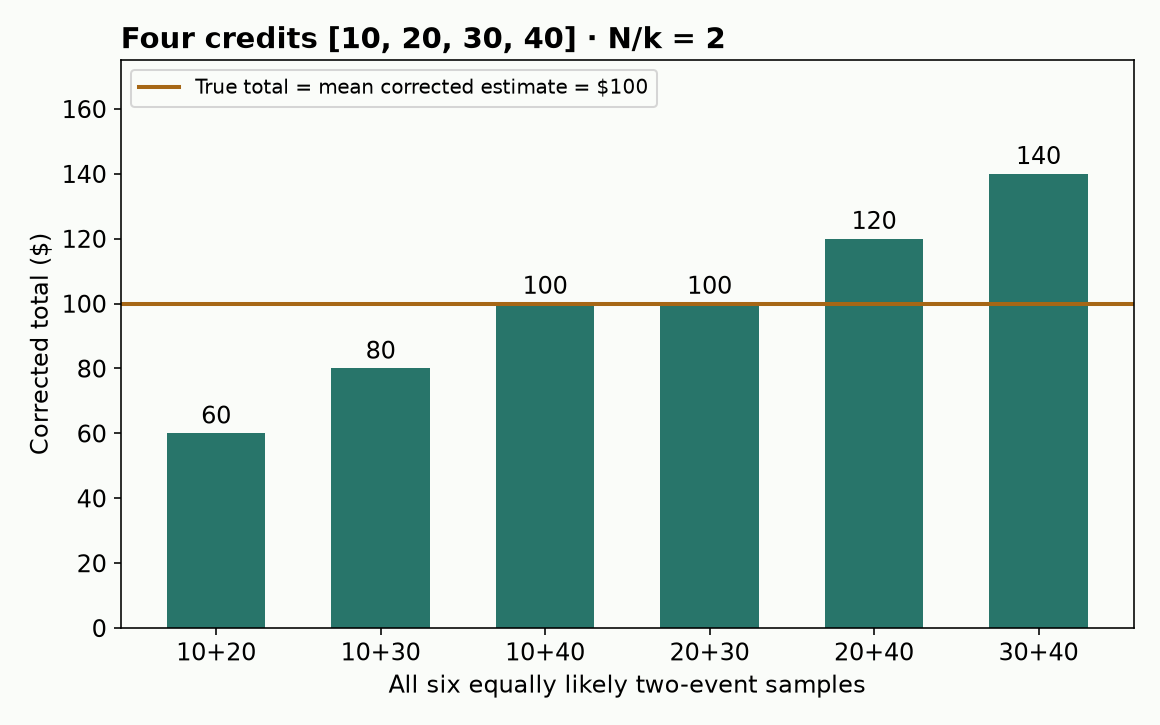<figcaption>Exact enumeration: correction averages to $100 but individual totals range from $60 to $140.</figcaption></figure>



## 2 · An architecture has an information budget

Before any attention layer or message passing, a retrieval or neighborhood sampler chooses records. That choice places an upper bound on what the predictor can distinguish.

**Worked impossibility:** retained events [10,20] could come from full histories [10,20,30,40] or[10,20,300,400]. The visible pair and full count N=4 are identical, but the totals are100 and730. Any deterministic function of just that pair and count returns the same answer for both. It cannot be exactly correct for both histories. Training can learn useful prior patterns; it cannot recover arbitrary missing evidence with certainty.

<figure class="context-figure" tabindex="0" role="region" aria-label="Course pipeline: time filtering precedes sampling or aggregation; full counts add information.">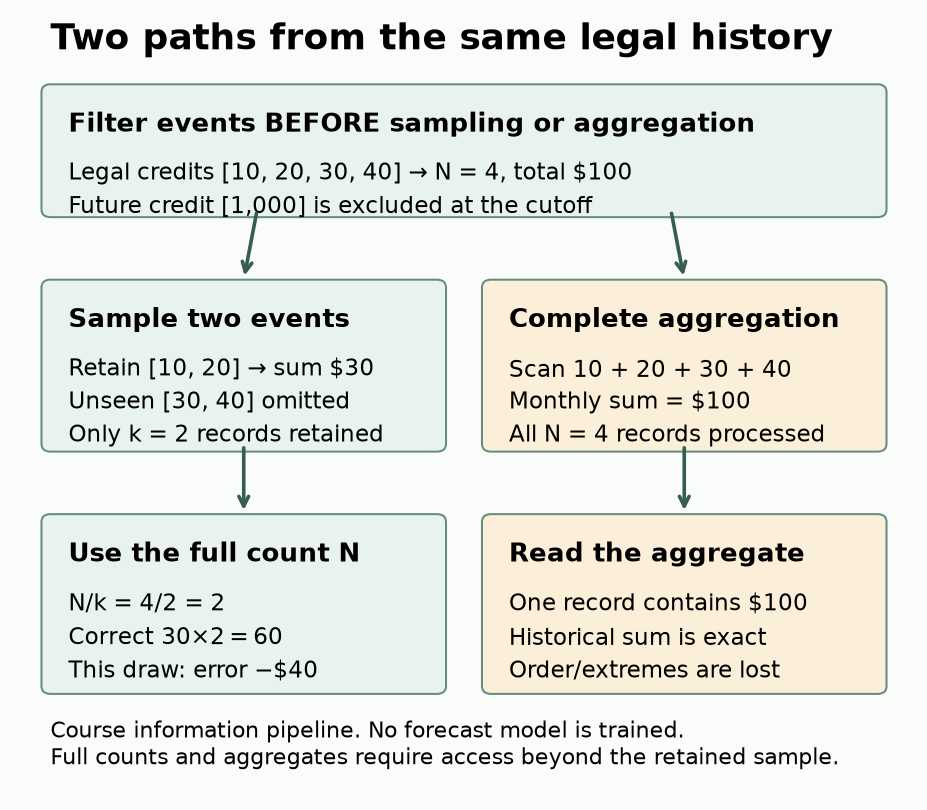<figcaption>Course pipeline: time filtering precedes sampling or aggregation; full counts add information.</figcaption></figure>

The diagram is the executed course information pipeline, not a new trained architecture. RT's cell-token context, Griffin's per-hop fanout and RelGT's sampled subgraph have different units and selection rules. Do not treat them as the same sampler merely because each is bounded. Revisit [B10's RT context](https://avistian.github.io/relational/lessons/b10-relational-transformer.html) for its cell-level path. [Context Window Failures, §2](https://arxiv.org/html/2609.00460v1#S2)

**Aggregation changes the input contract.** A complete sum can be computed before the predictor, so a single aggregate record carries information from many events. But computing that aggregate still requires access to all relevant history, possibly through a maintained index. Knowing N also requires full-count information. The corrected estimator therefore receives more information than a raw sampled-sum baseline.

A sum is sufficient to answer this particular sum query. This does not assert statistical sufficiency for an unknown future target. Two months can have identical totals and different last events, maxima or trends; monthly sums erase those differences. Select the summary for the question, not merely for its compactness.

## 3 · Time filtering comes first

The order is **query cutoff → eligible events → counts/aggregates/sampling → estimate**. If you aggregate everything first and then attach the query date, you have already mixed future amounts into the features.

The course fixture treats event day as availability day. In production, a backfilled event can have an old event date and a later arrival date. It needs both checks. Use the inherited control below to recall that distinction; this small illustration is separate from the B18 numerical grid.

<div class="temporal-panel"></div>
<p>At cutoff5, records(value,event day,arrival day)=(2,3,3),(8,4,7),(4,5,5),(10,8,8). Legal mean=(2+4)/2=3. Event-date-only mean=(2+8+4)/3=4.667; all-row mean=6. The late correction is not yet available.</p>

**Intervention test:** append a future credit with amount one billion dollars, then change it to minus one trillion. With the cutoff fixed, every historical estimate must remain unchanged. Our complete experiment performs this check for all 24 histories. This tests the implemented boundary; it does not prove an external dataset has correct arrival timestamps.

## 4 · Execute the entire frozen diagnostic

Every historical fixture totals$1,200. **Uniform** spreads it evenly. **Concentrated** puts 80% in one event and distributes 20% over the others. We use seeds 0/1/2, degrees 8/64/512/4096, budgets 8/32/128/512 and 100 repetitions. Within each repetition, smaller budgets use prefixes of the same random ordering. That pairs budget comparisons while preserving uniform sampling without replacement.

Each condition runs four arms: exact total, sampled sum, count-corrected sum and complete monthly aggregation. This is 96 conditions, 9,600 paired repetitions and 38,400 estimates. No model is trained; no condition is selected after seeing outcomes. [Complete frozen contract](https://avistian.github.io/relational/labs/b18-reproduction.md)

**Bias** is mean(prediction−true total): a negative value means underestimation. **RMSE** is the square root of the mean squared error, in dollars. It penalizes large errors and exposes variation that signed errors can cancel. A near-zero empirical bias across 100 draws is not proof of unbiasedness; the algebra and exhaustive four-event check establish that under the stated sampling rule.

**Prediction prompt:** will increasing k remove sampling bias, variance, or both? Run the complete grid below to inspect every condition.

**Author reference: degree 4,096, concentrated amounts, budget 32.** Each row summarizes 100 draws. Dollar amounts rounded to cents.

| Seed | Sample bias | Sample RMSE | Corrected bias | Corrected RMSE | Aggregate RMSE |
|---:|---:|---:|---:|---:|---:|
| 0 | -1178.93 | 1186.56 | 1497.51 | 17267.21 | 0.00 |
| 1 | -1198.12 | 1198.12 | -959.94 | 959.94 | 0.00 |
| 2 | -1178.93 | 1186.56 | 1497.51 | 17267.21 | 0.00 |


<figure class="context-figure" tabindex="0" role="region" aria-label="Measured reconstruction RMSE, three seeds, degree 4096. Concentration makes corrected totals variable.">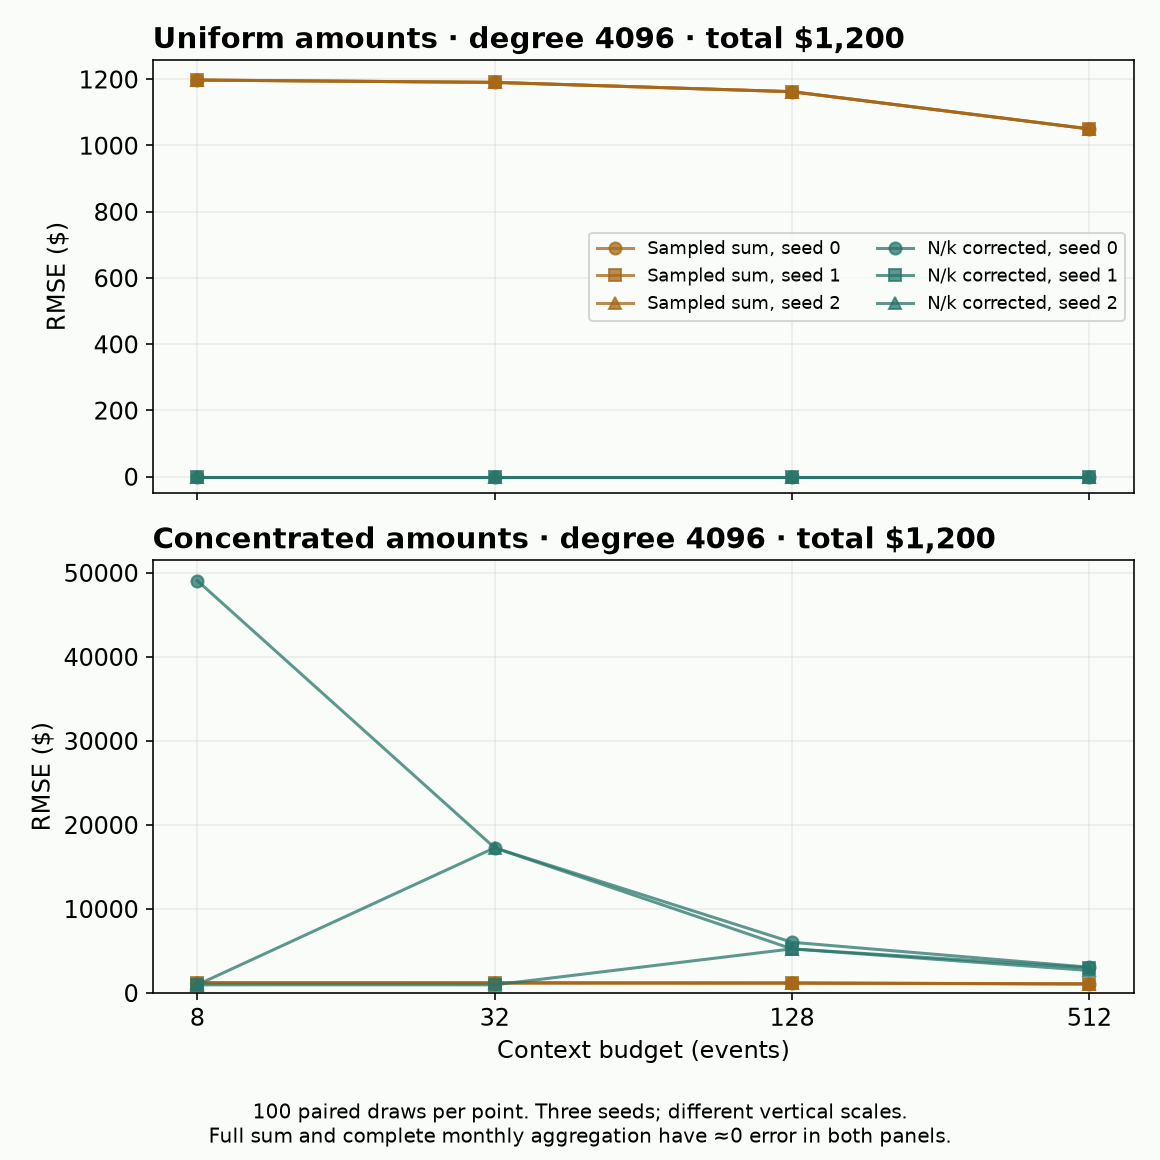<figcaption>Measured reconstruction RMSE, three seeds, degree 4096. Concentration makes corrected totals variable.</figcaption></figure>

Read the result conditionally. For uniform amounts, a single observed value plus exact N suffices to reconstruct the total. For concentrated amounts, the same correction may greatly overshoot when the rare large event is selected and undershoot when it is missed. As k reaches N, sampling uncertainty disappears. A larger budget helps on average; the error on each paired draw need not decrease monotonically.

The plot shows each seed separately. Three fixture seeds are not three independent real-world datasets; no confidence interval or broad performance ranking is inferred. Complete aggregation preserves the exact sum within floating-point precision, while processing the full eligible history. This is an information/access tradeoff, not a measured compute-speed advantage.

## 5 · What the Animus paper actually supports

**Primary reading:** [Context Window Failures in Relational Foundation Models, v1](https://arxiv.org/html/2609.00460v1), §3–4, Tables 1–2 and Appendix B. Animus is a synthetic financial database. Its prediction task is next-month income from records available by the cutoff. The paper compares raw events with monthly aggregation and reports substantial gains for some models. It is a constructed failure study, not an estimate of how common this failure is in industry.

There are three reasons to read the run records before claiming reproduction:

1. **Scores conflict.** Main Table 3 reports RT R²+.1836/raw and+.6541/aggregate. Appendix B's RT test entries are negative. We preserve both; we do not repair a sign by assumption.
2. **Selection needs clarification.** Several appendix captions designate the best test R². Reconstructing that reported table is distinct from a prospective experiment whose configuration is selected only on validation. Even validation score labels alone do not establish the checkpoint-selection code.
3. **The subgroup is selected.** Tables 2/9 cover 474 of 10,000 test customers, selected using post-cutoff behavior. Those retrospective bins cannot become inference-time features or stand in for a full-population historical-degree analysis.

The paper motivates sampling loss with a sum over next-month credits. That algebra is a statement about partially observed sums; it does not make future credits legal predictor inputs. Our lab establishes historical reconstruction loss only. Predictive consequences require the full forecasting experiment. [Paper §3, Tables 3,5–6,9](https://arxiv.org/html/2609.00460v1#S3)

**Named reproduction lane — B18-ANIMUS-RT-RAW-AGG:** preserve raw/aggregate × depths 6/12 × three learning rates: all 12 configurations at the published dimensions/schedule. Original data/generator, initialization, seeds, exact task protocol and reconciled score records are not authenticated. The supplied audit verifies archived source bytes; its paper command refuses to launch. Full reproduction remains **NOT_RUN / INCOMPLETE_SOURCE_PROTOCOL_GATE**. An audit pass is not benchmark execution. [Exact contract, commands and missing fields](https://avistian.github.io/relational/labs/b18-reproduction.md)



## Run contract

Tier C historical-sum diagnostic. No training/model library is hidden. All load-bearing code is visible below. The three TODOs are called by the final experiment. This notebook uses only NumPy plus Python standard libraries. No files, installs, credentials or repository imports are needed. Tested versions are archived in evidence/b18/environment.json. Predictions below are historical estimates in dollars, never forecasts. Do not use this notebook to claim Animus reproduction.

In [ ]:
# @colab-bootstrap
import numpy as np
import itertools, unittest, json, gzip
from pathlib import Path

## PROVIDED · behavioral checks

The correction check enumerates all six equally likely pairs, independently of the Monte Carlo grid. Time checks include an event exactly on the cutoff. Metric checks use hand-computable errors.

In [ ]:
class Boundaries(unittest.TestCase):
    def test_history(self):
        rows=[dict(id='a',day=29,kind='credit',amount=10.,month=1),dict(id='b',day=30,kind='credit',amount=20.,month=1),dict(id='c',day=31,kind='credit',amount=1e9,month=2),dict(id='d',day=20,kind='debit',amount=300.,month=1)]
        self.assertEqual([r['id'] for r in eligible_history(rows,30)],['a','b'])
        rows[2]['amount']=-1e12
        self.assertEqual(sum(r['amount'] for r in eligible_history(rows,30)),30.)
        self.assertEqual(eligible_history(rows,0),[])
        with self.assertRaises(ValueError):eligible_history(rows+[rows[0]],30)
        with self.assertRaises(ValueError):eligible_history([dict(rows[0],amount=float('nan'))],30)
    def test_correction(self):
        values=[1.,2.,7.,10.]
        estimates=[corrected_total(np.array(s),4) for s in itertools.combinations(values,2)]
        self.assertAlmostEqual(sum(estimates)/6,20.)
        self.assertGreater(np.var(estimates),0.)
        self.assertEqual(corrected_total(np.array([]),0),0.)
        self.assertEqual(corrected_total(np.array(values),4),20.)
        with self.assertRaises(ValueError):corrected_total(np.array([]),4)
        with self.assertRaises(ValueError):corrected_total(np.array(values),2)
    def test_metrics(self):
        r=stratified_metrics([8,8,64,64],[1.,3.,2.,4.],[2.,2.,1.,1.])
        self.assertEqual(r['8'],dict(n=2,bias=0.,rmse=1.))
        self.assertAlmostEqual(r['64']['bias'],2.)
        self.assertAlmostEqual(r['64']['rmse'],np.sqrt(5))
        with self.assertRaises(ValueError):stratified_metrics([8],[1,2],[1])
        with self.assertRaises(ValueError):stratified_metrics([8],[float('nan')],[1])

## TODO · eligible_history

Return copied legal credit rows in original order, using day≤cutoff. Reject duplicate IDs and nonfinite times/amounts. Why: filtering after aggregation cannot undo leakage. This fixture assumes event day equals arrival day.

In [ ]:
def eligible_history(rows,cutoff):
    raise NotImplementedError("Implement eligible_history")

### CHECK · run before continuing

In [ ]:
Boundaries('test_history').debug()
print('eligible_history: passed')

## TODO · corrected_total

Compute the uniform-sampling total estimator. Validate finite one-dimensional amounts and integer N≥k. Return 0 for N=k=0; reject k=0<N. Why: the full-count assumption must be visible in the interface.

In [ ]:
def corrected_total(sample,population_size):
    raise NotImplementedError("Implement corrected_total")

### CHECK · run before continuing

In [ ]:
Boundaries('test_correction').debug()
print('corrected_total: passed')

## TODO · stratified_metrics

Align nonempty degree, prediction and target vectors; reject nonfinite inputs and invalid degrees. Return a dictionary keyed by string degree, with n, signed bias and RMSE. Why: pooled errors can hide a high-degree failure.

In [ ]:
def stratified_metrics(degrees,predictions,targets):
    raise NotImplementedError("Implement stratified_metrics")

### CHECK · run before continuing

In [ ]:
Boundaries('test_metrics').debug()
print('stratified_metrics: passed')

## PROVIDED · fixed histories and complete aggregation

Amounts are USD1200 total. A concentrated history has one USD960 event. Seeds shuffle its position. Extra debit and future credit exercise your filter. The aggregate consumes every filtered row; it is not built from the sampled prefix.

In [ ]:
def fixture(seed,degree,shape):
    """Fixed USD1200 historical mass; day31 future credit is an exclusion test."""
    rng=np.random.default_rng(np.random.SeedSequence([seed,degree,shape=='concentrated',18]))
    values=np.full(degree,1200./degree)
    if shape=='concentrated':
        values[:]=240./(degree-1);values[0]=960.
    values=values[rng.permutation(degree)]
    rows=[dict(id=f'e{i}',day=i%28+1,month=1,kind='credit',amount=float(v)) for i,v in enumerate(values)]
    rows+=[dict(id='debit',day=15,month=1,kind='debit',amount=700.),dict(id='future',day=31,month=2,kind='credit',amount=1e9)]
    return rows,rng

def monthly_total(rows):
    """Aggregate every eligible event, retaining (month,event kind) groups."""
    groups={}
    for row in rows:
        key=(row['month'],row['kind'])
        groups[key]=groups.get(key,0.)+row['amount']
    return float(sum(groups.values()))

## PROVIDED · paired sampling and reporting

One random ordering per repetition supplies every budget prefix. Your eligibility, correction and stratification functions are invoked below. All conditions remain in the report; none is selected by its score.

In [ ]:
def run_experiment():
    """Execute the entire frozen paired grid; learner functions stay live."""
    fixtures=[];conditions=[]
    for seed in [0,1,2]:
        for degree in [8,64,512,4096]:
            for shape in ['uniform','concentrated']:
                rows,rng=fixture(seed,degree,shape)
                history=eligible_history(rows,30)
                values=np.array([r['amount'] for r in history]);truth=float(values.sum())
                # One prefix per repetition couples budget comparisons without looking at results.
                draws=[rng.permutation(degree)[:min(512,degree)].tolist() for _ in range(100)]
                changed=[dict(r,amount=-1e12) if r['id']=='future' else dict(r) for r in rows]
                assert eligible_history(changed,30)==history
                agg=monthly_total(history)
                fixtures.append(dict(seed=seed,degree=degree,shape=shape,rows=rows,draws=draws,truth=truth,future_invariant=True))
                for budget in [8,32,128,512]:
                    estimates={arm:[] for arm in ['exact','sampled','corrected','aggregate']}
                    for draw in draws:
                        sample=values[draw[:min(budget,degree)]]
                        estimates['exact'].append(truth)
                        estimates['sampled'].append(float(sample.sum()))
                        estimates['corrected'].append(corrected_total(sample,degree))
                        estimates['aggregate'].append(agg)
                    metrics={arm:stratified_metrics([degree]*100,pred,[truth]*100)[str(degree)] for arm,pred in estimates.items()}
                    conditions.append(dict(seed=seed,degree=degree,shape=shape,budget=budget,k=min(budget,degree),estimates=estimates,metrics=metrics))
    return dict(experiment='B18-CONTEXT-SUFFICIENCY',status='COMPLETE_MECHANISM_DIAGNOSTIC',fixtures=fixtures,conditions=conditions,cloud_usd=0,paper_status='INCOMPLETE_SOURCE_PROTOCOL_GATE',learner='PENDING_WRITTEN_DEFENSE')

## RUN · complete live grid

These outputs come from the current kernel. Contrast them with the author reference above. The compressed result preserves all original rows and sampled indices for independent replay.

In [ ]:
report=run_experiment()
assert len(report['conditions'])==96
Path('b18-diagnostic.json.gz').write_bytes(gzip.compress(json.dumps(report,sort_keys=True,separators=(',',':')).encode(),mtime=0))
print('seed degree shape budget sampled-RMSE corrected-RMSE')
for c in report['conditions']:
    print(c['seed'],c['degree'],c['shape'],c['budget'],round(c['metrics']['sampled']['rmse'],2),round(c['metrics']['corrected']['rmse'],2))

## EXIT · defend what the calculation establishes

In 150–200 words derive the correction using inclusion probabilities; explain its variance in the concentrated case; identify the extra full-count access; state the temporal filter and the separate forecasting question. Propose a complete-population degree-stratified falsification test for B24. Ask your teacher for feedback and revisit in 1/7/30 days.

In [ ]:
assert sum(len(c['estimates'][a]) for c in report['conditions'] for a in c['estimates'])==38400
assert all(f['future_invariant'] for f in report['fixtures'])
print('COMPLETE_MECHANISM_DIAGNOSTIC; paper NOT_RUN; learner PENDING_WRITTEN_DEFENSE')

## Paper-results lane · source audit and explicit refusal

The embedded source packet supplies the primary paper, dated limited search receipts and complete unresolved 12-configuration RT contract. Audit success authenticates bytes. The paper command deliberately refuses execution and is not an implemented trainer. No claim of complete runnable Animus reproduction is made while original data, code and protocol remain unresolved. Paid compute USD0; all author numerical work shares 3600seconds. Live Colab frontend is not checked by local execution.

In [ ]:
import base64,io,zipfile,subprocess,sys
packet=Path('b18-source-packet');packet.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(base64.b64decode('...'))) as archive:
    archive.extractall(packet)
audit=subprocess.run([sys.executable,str(packet/'_reproduce_b18.py'),'--phase','audit'],capture_output=True,text=True,check=True)
print(audit.stdout)
print((packet/'b18-reproduction.md').read_text())

In [ ]:
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    subprocess.run([sys.executable,str(packet/'_reproduce_b18.py'),'--phase','paper'],check=True)
else:
    print('NOT_RUN / INCOMPLETE_SOURCE_PROTOCOL_GATE')